In [1]:
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from energy_sights.config import PROCESSED_DATA_DIR
from energy_sights.modeling.train import ModelTrainer
from energy_sights.modeling.evaluate import evaluate_regression, print_metrics, plot_residuals, \
    plot_features_importance, print_feature_importances
from energy_sights.modeling.tuning import tune_model
from energy_sights.logging_config import setup_logging
from energy_sights.preprocessing import nan_percent, numeric_describe
from energy_sights.plots import interactive_distribution
from energy_sights.modeling import evaluate
from energy_sights.modeling import tuning
from importlib import reload

2026-02-17 22:30:26.302 | INFO     | energy_sights.config:<module>:11 - PROJ_ROOT path is: C:\ML_projects\energy_sights


2026-02-17 22:30:27 | INFO     | energy_sights.preprocessing - Starting the Preprocessing
2026-02-17 22:30:27.256 | INFO     | energy_sights.preprocessing:<module>:12 - Starting the Preprocessing
2026-02-17 22:30:27 | SUCCESS  | energy_sights.preprocessing - End of the preprocessing
2026-02-17 22:30:27.261 | SUCCESS  | energy_sights.preprocessing:<module>:90 - End of the preprocessing


In [2]:
reload(evaluate)
reload(tuning)

<module 'energy_sights.modeling.tuning' from 'C:\\ML_projects\\energy_sights\\energy_sights\\modeling\\tuning.py'>

In [4]:
setup_logging()

In [5]:
data_path: Path = PROCESSED_DATA_DIR / 'processed_data.csv'

In [6]:
df = pd.read_csv(filepath_or_buffer=data_path)

In [7]:
df.head()

,PrimaryPropertyType,PropertyGFATotal,Neighborhood,NumberofFloors,Latitude,Longitude,SiteEnergyUse(kBtu),TotalGHGEmissions,IsComplex,BuildingAge,AverageFloorArea,DistToCenter,ParkingRatio
0,Hotel,88434,Downtown,12,47.61220,-122.33799,7226362.5,249.98,0,89,7369.500000,11742.615082,0.000000
1,Hotel,103566,Downtown,11,47.61317,-122.33393,8387933.0,295.86,0,20,9415.090909,11743.170496,0.145453
2,Hotel,956110,Downtown,41,47.61393,-122.33810,72587024.0,2089.28,0,47,23319.756098,11742.794402,0.205748
3,Hotel,61320,Downtown,10,47.61412,-122.33664,6794584.0,286.43,0,90,6132.000000,11742.976556,0.000000
4,Hotel,175580,Downtown,18,47.61375,-122.34047,14172606.0,505.01,0,36,9754.444444,11742.512927,0.353115


In [8]:
# let's check the quality of the data
df.info(memory_usage='deep')

<class 'pandas.DataFrame'>
RangeIndex: 1491 entries, 0 to 1490
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   PrimaryPropertyType  1491 non-null   str    
 1   PropertyGFATotal     1491 non-null   int64  
 2   Neighborhood         1491 non-null   str    
 3   NumberofFloors       1491 non-null   int64  
 4   Latitude             1491 non-null   float64
 5   Longitude            1491 non-null   float64
 6   SiteEnergyUse(kBtu)  1491 non-null   float64
 7   TotalGHGEmissions    1491 non-null   float64
 8   IsComplex            1491 non-null   int64  
 9   BuildingAge          1491 non-null   int64  
 10  AverageFloorArea     1491 non-null   float64
 11  DistToCenter         1491 non-null   float64
 12  ParkingRatio         1491 non-null   float64
dtypes: float64(7), int64(4), str(2)
memory usage: 308.3 KB


In [9]:
df.columns.tolist()

['PrimaryPropertyType',
 'PropertyGFATotal',
 'Neighborhood',
 'NumberofFloors',
 'Latitude',
 'Longitude',
 'SiteEnergyUse(kBtu)',
 'TotalGHGEmissions',
 'IsComplex',
 'BuildingAge',
 'AverageFloorArea',
 'DistToCenter',
 'ParkingRatio']

In [10]:
# let's also check the nan values
nan_percent(df=df)

PrimaryPropertyType ->  0.0000 %

PropertyGFATotal ->  0.0000 %

Neighborhood ->  0.0000 %

NumberofFloors ->  0.0000 %

Latitude ->  0.0000 %

Longitude ->  0.0000 %

SiteEnergyUse(kBtu) ->  0.0000 %

TotalGHGEmissions ->  0.0000 %

IsComplex ->  0.0000 %

BuildingAge ->  0.0000 %

AverageFloorArea ->  0.0000 %

DistToCenter ->  0.0000 %

ParkingRatio ->  0.0000 %



In [11]:
df.select_dtypes(include='string').nunique().rename('Count')

PrimaryPropertyType    16
Neighborhood           13
Name: Count, dtype: int64

In [12]:
# let's study a bit the distribution of the target to clean all the outliers to ensure the best performance with the model
q_98: float = df['SiteEnergyUse(kBtu)'].quantile(q=.98)

In [13]:
# let's filter the values to remove all the values above this quantile
df_copy = df.copy()

In [14]:
final_df = df_copy[df_copy['SiteEnergyUse(kBtu)'] < q_98]

In [15]:
# shape of the final df
final_df.shape

(1461, 13)

In [16]:
# Distribution of the target
interactive_distribution(df=final_df, col='SiteEnergyUse(kBtu)')

In [17]:
# let's see the statistics
numeric_describe(df=final_df, col='SiteEnergyUse(kBtu)').head(n=10)

count     1.461000e+03
mean      6.028124e+06
std       8.716702e+06
min       5.713320e+04
25%       1.217509e+06
50%       2.603931e+06
75%       6.797647e+06
max       5.648520e+07
mode_1    5.713320e+04
mode_2    7.971180e+04
Name: SiteEnergyUse(kBtu), dtype: float64

In [18]:
X = final_df.drop(columns=['SiteEnergyUse(kBtu)', 'TotalGHGEmissions'])
y = final_df.filter(items=['SiteEnergyUse(kBtu)'])

In [19]:
# let's split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2)

In [20]:
X_train.head()

,PrimaryPropertyType,PropertyGFATotal,Neighborhood,NumberofFloors,Latitude,Longitude,IsComplex,BuildingAge,AverageFloorArea,DistToCenter,ParkingRatio
1415,Large Office,162157,Greater Duwamish,4,47.57350,-122.32239,0,11,40539.250000,11740.053747,0.000000
1093,Warehouse,43200,East,2,47.61467,-122.31777,0,101,21600.000000,11745.119925,0.000000
601,Small- and Mid-Sized Office,28800,Downtown,3,47.61285,-122.34817,0,108,9600.000000,11741.563548,0.000000
215,Large Office,1400000,Downtown,55,47.60723,-122.33611,0,28,25454.545455,11742.272528,0.203571
1226,Retail Store,28800,Downtown,3,47.59697,-122.32474,0,103,9600.000000,11742.391844,0.000000


In [21]:
# let's now charge the model
trainer_boost = ModelTrainer(model_type='xgboost')

In [22]:
# let's build the model
base_model_boost = trainer_boost.build_pipeline(use_log_target=True)


2026-02-17 22:32:43 | INFO     | energy_sights.modeling.train - Model configuration with a logarithm transformation of the target .
2026-02-17 22:32:43.741 | INFO     | energy_sights.modeling.train:build_pipeline:85 - Model configuration with a logarithm transformation of the target .


In [23]:
# now let's tune the model to find the best model
best_model = tune_model(model=base_model_boost,
                        X_train=X_train,
                        y_train=y_train,
                        model_type='xgboost')

2026-02-17 22:32:43 | INFO     | energy_sights.modeling.tuning - Start of the tuning the: 2026-02-17 22:32:43.951743
2026-02-17 22:32:43.951 | INFO     | energy_sights.modeling.tuning:tune_model:47 - Start of the tuning the: 2026-02-17 22:32:43.951743
Fitting 5 folds for each of 20 candidates, totalling 100 fits
The best parameters finds are: {'regressor__model__subsample': 0.8, 'regressor__model__n_estimators': 150, 'regressor__model__max_depth': 3, 'regressor__model__learning_rate': 0.1, 'regressor__model__lambda': 1.5, 'regressor__model__gamma': 0.2, 'regressor__model__colsample_bytree': 0.8, 'regressor__model__alpha': 1.0}
The best Score (RMSE roughly): 5330790.54


In [24]:
# evaluation of the model
y_pred = best_model.predict(X_test)

In [25]:
y_pred

array([[1.54159050e+06],
       [6.73493900e+06],
       [1.52496488e+06],
       [1.89519275e+06],
       [8.22250688e+05],
       [2.42071500e+06],
       [1.35110988e+06],
       [1.27568925e+06],
       [1.69389200e+07],
       [7.30715200e+06],
       [1.31749000e+06],
       [4.57167400e+06],
       [7.39999875e+05],
       [1.05253550e+06],
       [3.75583650e+06],
       [1.37308850e+06],
       [2.78263050e+06],
       [6.32175438e+05],
       [7.62285812e+05],
       [1.49864325e+06],
       [9.84984938e+05],
       [1.37464900e+06],
       [7.04192812e+05],
       [6.04554250e+06],
       [2.36305225e+06],
       [8.62276500e+06],
       [9.93791600e+06],
       [1.35299900e+06],
       [1.47070438e+06],
       [7.94415600e+06],
       [6.80355600e+06],
       [8.88586062e+05],
       [1.13970775e+06],
       [1.69567000e+07],
       [4.87953000e+06],
       [3.96920175e+06],
       [3.35360050e+06],
       [8.17113312e+05],
       [1.00572806e+06],
       [6.65300900e+06],


In [26]:
y_pred.shape

(293, 1)

In [27]:
y_pred_train = best_model.predict(X_train)

In [28]:
y_pred_train[0:5]

array([[1.3114522e+07],
       [9.0943619e+05],
       [1.2708442e+06],
       [3.6638940e+07],
       [1.0281329e+06]], dtype=float32)

In [29]:
# evaluation of the model
print_metrics(metrics=evaluate_regression(y_true=y_train, y_pred=y_pred_train, model_name='xgboost'))


 Model performance : xgboost
  RMSE (Root Mean Squared Error) : 4,343,733.65
  MAE  (Mean Absolute Error)     : 2,017,298.88
  MAPE (Error %)           : 44.42%
  R²   (Score explication)  : 0.7524


In [30]:
# now let's evaluate the model
xgboost_metrics = evaluate_regression(y_test, y_pred, model_name='xgboost')

In [31]:
# let's see all the metrics of this model
print_metrics(metrics=xgboost_metrics)


 Model performance : xgboost
  RMSE (Root Mean Squared Error) : 5,551,583.87
  MAE  (Mean Absolute Error)     : 2,616,544.50
  MAPE (Error %)           : 69.04%
  R²   (Score explication)  : 0.5881


In [32]:
type(y_test)

pandas.DataFrame

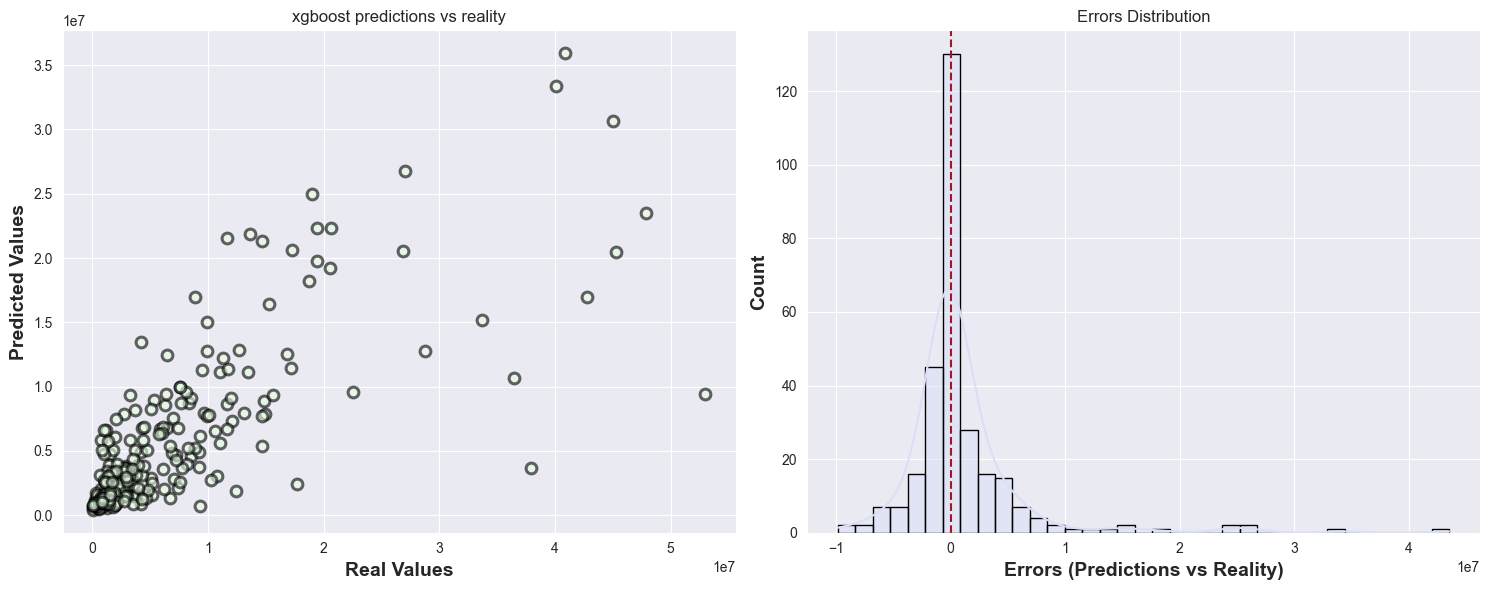

In [33]:
# let's now plot the residuals also
plot_residuals(y_true=y_test, y_pred=y_pred, model_name='xgboost')

In [34]:
# let's do it from scratch
features_name: list[str] = X_train.columns.tolist()
importances = best_model.regressor_.named_steps['model'].feature_importances_

In [35]:
fea_df = pd.DataFrame(data={
    'Features': features_name,
    'Importances': importances
})

In [36]:
fea_df = fea_df.sort_values(by='Importances', kind='quicksort', ascending=False)

In [37]:
fea_df

,Features,Importances
1,PropertyGFATotal,0.445853
0,PrimaryPropertyType,0.190443
3,NumberofFloors,0.115934
8,AverageFloorArea,0.063953
9,DistToCenter,0.028487
6,IsComplex,0.028097
2,Neighborhood,0.026866
5,Longitude,0.026116
10,ParkingRatio,0.025189
7,BuildingAge,0.025126


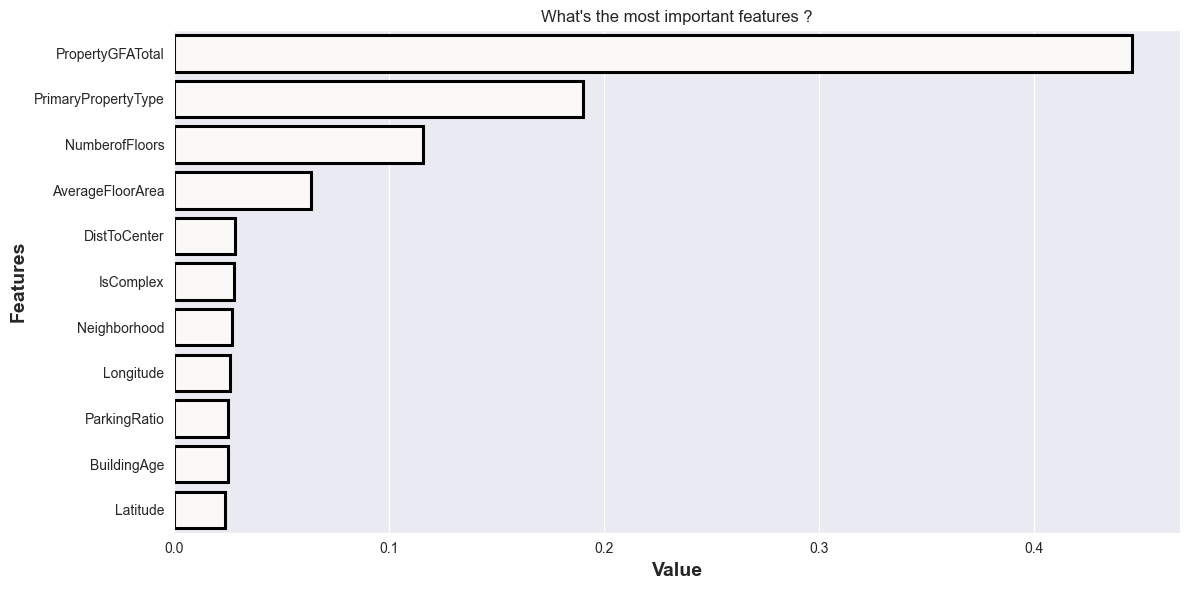

In [38]:
# let's plt the importance of the features in the trainset
plot_features_importance(model=best_model, feature_names=X_train.columns.tolist())

### Improvement of the model with the removal of the useless features

In [39]:
# now let's remove all the useless column and let's see how the model learn
X_2 = X.drop(columns=['Latitude', 'ParkingRatio', 'Longitude', 'DistToCenter', 'IsComplex'])
y2 = y

In [40]:
# the split of the data
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_2, y2, test_size=.2)

In [41]:
# training with the best model
best_model_boost2 = tune_model(model=base_model_boost,
                               X_train=X_train2,
                               y_train=y_train2,
                               model_type='xgboost',
                               n_iter=30)

2026-02-17 22:33:33 | INFO     | energy_sights.modeling.tuning - Start of the tuning the: 2026-02-17 22:33:33.725370
2026-02-17 22:33:33.725 | INFO     | energy_sights.modeling.tuning:tune_model:47 - Start of the tuning the: 2026-02-17 22:33:33.725370
Fitting 5 folds for each of 30 candidates, totalling 150 fits
The best parameters finds are: {'regressor__model__subsample': 0.8, 'regressor__model__n_estimators': 120, 'regressor__model__max_depth': 4, 'regressor__model__learning_rate': 0.1, 'regressor__model__lambda': 1, 'regressor__model__gamma': 0.1, 'regressor__model__colsample_bytree': 0.6, 'regressor__model__alpha': 0}
The best Score (RMSE roughly): 5622973.90


In [42]:
# Evaluation the performance of the model
y_pred_train2 = best_model_boost2.predict(X_train2)

In [43]:
metrics_train2 = evaluate_regression(y_true=y_train2,
                                     y_pred=y_pred_train2,
                                     model_name='xgboost')

In [44]:
print_metrics(metrics=metrics_train2)


 Model performance : xgboost
  RMSE (Root Mean Squared Error) : 4,220,084.77
  MAE  (Mean Absolute Error)     : 1,944,896.00
  MAPE (Error %)           : 41.57%
  R²   (Score explication)  : 0.7683


In [45]:
# on the test set we have
y_pred_test2 = best_model_boost2.predict(X_test2)

In [46]:
print_metrics(metrics=evaluate_regression(
    y_true=y_test2,
    y_pred=y_pred_test2,
    model_name='xgboost'
))


 Model performance : xgboost
  RMSE (Root Mean Squared Error) : 4,979,686.21
  MAE  (Mean Absolute Error)     : 2,550,684.00
  MAPE (Error %)           : 69.57%
  R²   (Score explication)  : 0.6566


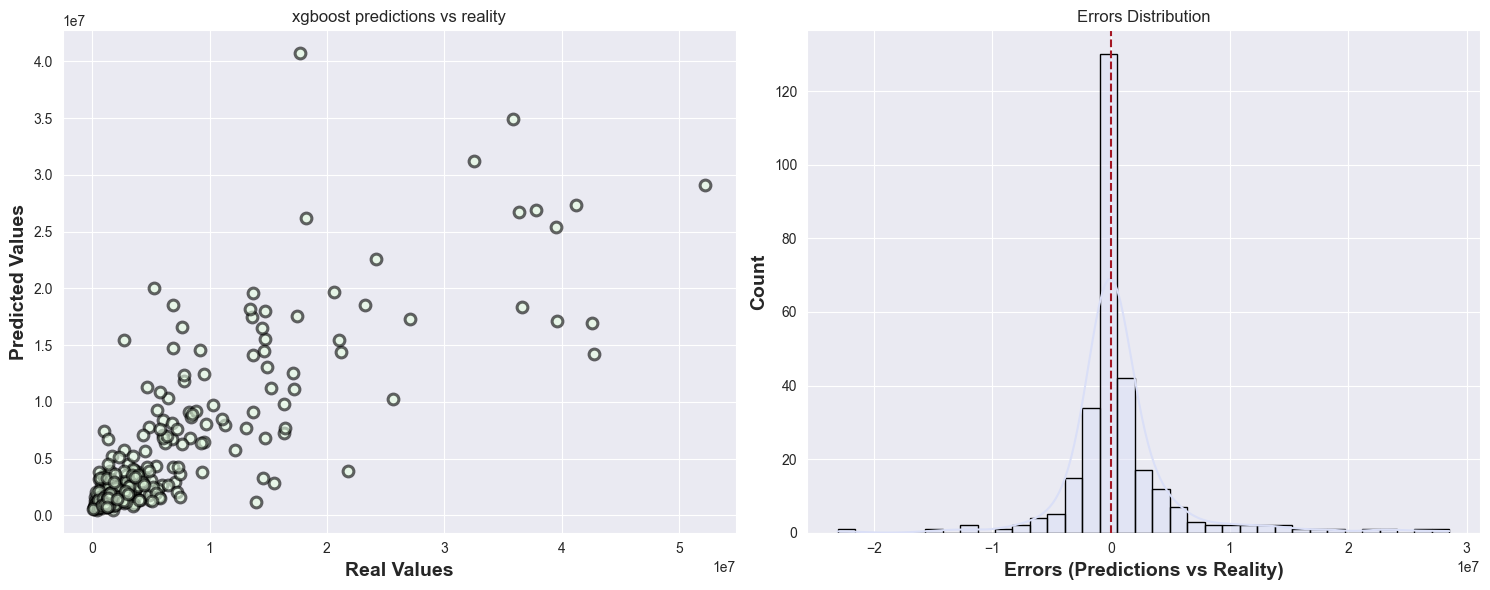

In [47]:
# Plot the residuals
plot_residuals(y_true=y_test2, y_pred=y_pred_test2, model_name='xgboost')

## RandomForest Model

In [48]:
# let's now use the RandomForestRegressor model
trainer_forest = ModelTrainer(model_type='random_forest')

In [49]:
# the base model
base_model_forest = trainer_forest.build_pipeline(use_log_target=True)

2026-02-17 22:34:14 | INFO     | energy_sights.modeling.train - Model configuration with a logarithm transformation of the target .
2026-02-17 22:34:14.421 | INFO     | energy_sights.modeling.train:build_pipeline:85 - Model configuration with a logarithm transformation of the target .


In [50]:
y_train.shape

(1168, 1)

In [51]:
# let's squeeze the array of the y_train values
y_train_squeezed = y_train.squeeze()

In [52]:
y_train_squeezed.shape

(1168,)

In [53]:
best_forest_model = tune_model(model=base_model_forest,
                               X_train=X_train,
                               y_train=y_train_squeezed,
                               model_type='random_forest',
                               n_iter=30)

2026-02-17 22:34:15 | INFO     | energy_sights.modeling.tuning - Start of the tuning the: 2026-02-17 22:34:15.132621
2026-02-17 22:34:15.132 | INFO     | energy_sights.modeling.tuning:tune_model:47 - Start of the tuning the: 2026-02-17 22:34:15.132621
Fitting 5 folds for each of 30 candidates, totalling 150 fits
The best parameters finds are: {'regressor__model__n_estimators': 150, 'regressor__model__min_samples_split': 15, 'regressor__model__min_samples_leaf': 10, 'regressor__model__max_depth': 15, 'regressor__model__bootstrap': True}
The best Score (RMSE roughly): 5284510.62


In [54]:
y_pred_train1 = best_forest_model.predict(X_train)

In [55]:
forest_train_metrics = evaluate_regression(y_true=y_train, y_pred=y_pred_train1, model_name='random_forest')

In [56]:
print_metrics(forest_train_metrics)


 Model performance : random_forest
  RMSE (Root Mean Squared Error) : 4,628,889.50
  MAE  (Mean Absolute Error)     : 2,179,199.94
  MAPE (Error %)           : 49.16%
  R²   (Score explication)  : 0.7188


In [57]:
# now let's try it on the test set
y_pred_test = best_forest_model.predict(X_test)

In [58]:
forest_test_metrics = evaluate_regression(y_true=y_test, y_pred=y_pred_test, model_name='random_forest')

In [59]:
print_metrics(metrics=forest_test_metrics)


 Model performance : random_forest
  RMSE (Root Mean Squared Error) : 5,912,844.60
  MAE  (Mean Absolute Error)     : 2,784,072.99
  MAPE (Error %)           : 72.14%
  R²   (Score explication)  : 0.5328


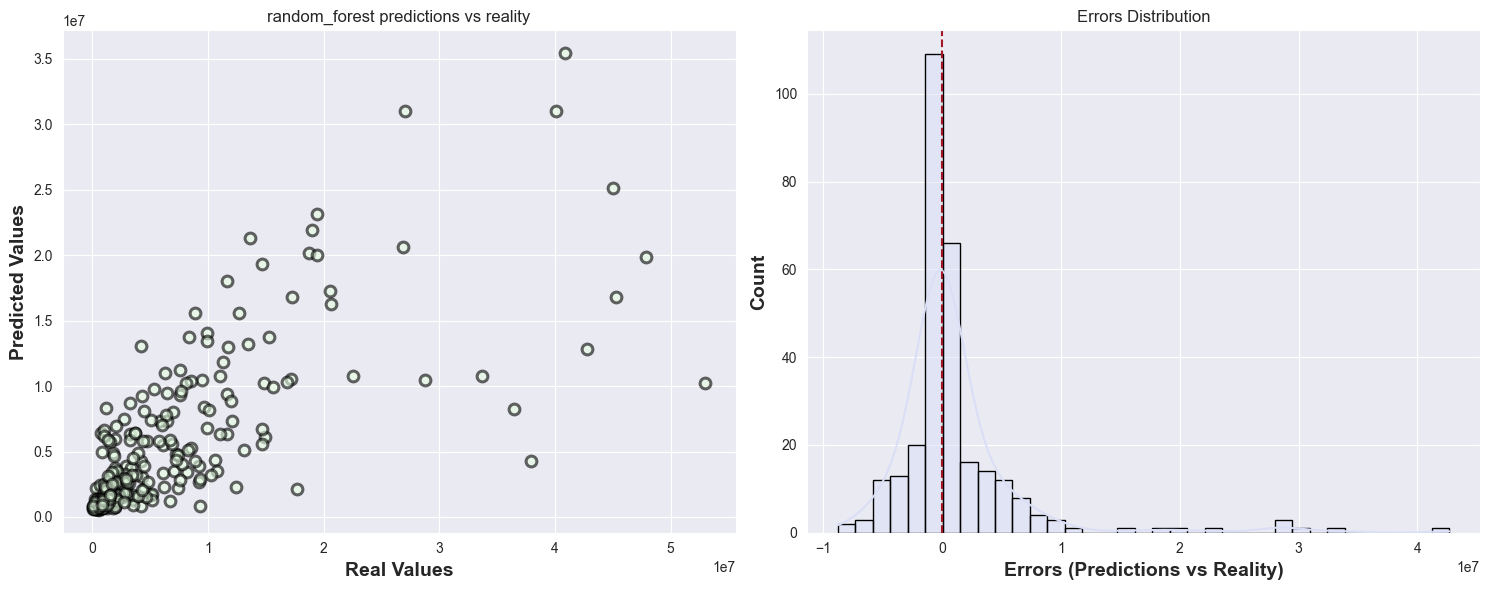

In [60]:
plot_residuals(y_true=y_test,
               y_pred=y_pred_test,
               model_name='random_forest')

In [61]:
# let's now do the same thing with the random_forest model
best_forest_model2 = tune_model(model=base_model_forest,
                                X_train=X_train2,
                                y_train=y_train2.squeeze(),
                                model_type='random_forest',
                                n_iter=30)

2026-02-17 22:35:26 | INFO     | energy_sights.modeling.tuning - Start of the tuning the: 2026-02-17 22:35:26.963229
2026-02-17 22:35:26.963 | INFO     | energy_sights.modeling.tuning:tune_model:47 - Start of the tuning the: 2026-02-17 22:35:26.963229
Fitting 5 folds for each of 30 candidates, totalling 150 fits
The best parameters finds are: {'regressor__model__n_estimators': 500, 'regressor__model__min_samples_split': 15, 'regressor__model__min_samples_leaf': 5, 'regressor__model__max_depth': 20, 'regressor__model__bootstrap': True}
The best Score (RMSE roughly): 5739206.16


In [62]:
y_pred_train2 = best_forest_model2.predict(X_train2)

In [63]:
print_metrics(metrics=evaluate_regression(y_true=y_train2,
                                          y_pred=y_pred_train2,
                                          model_name='random_forest'))


 Model performance : random_forest
  RMSE (Root Mean Squared Error) : 4,617,319.73
  MAE  (Mean Absolute Error)     : 2,098,619.14
  MAPE (Error %)           : 45.25%
  R²   (Score explication)  : 0.7226


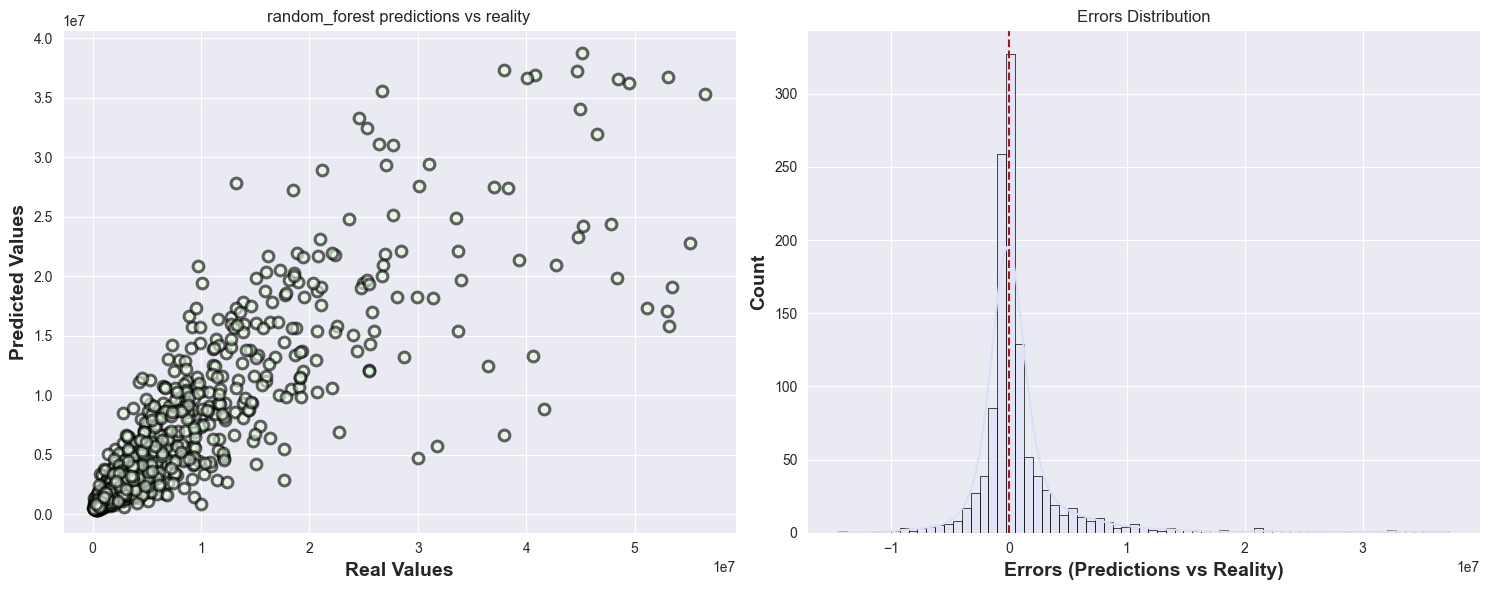

In [64]:
plot_residuals(y_true=y_train2,
               y_pred=y_pred_train2,
               model_name='random_forest')

In [65]:
# On the test data let's see what we have
y_pred_test2 = best_forest_model2.predict(X_test2)

In [66]:
print_metrics(metrics=evaluate_regression(y_true=y_test2,
                                          y_pred=y_pred_test2,
                                          model_name='random_forest'))


 Model performance : random_forest
  RMSE (Root Mean Squared Error) : 4,626,577.66
  MAE  (Mean Absolute Error)     : 2,440,846.27
  MAPE (Error %)           : 67.19%
  R²   (Score explication)  : 0.7036


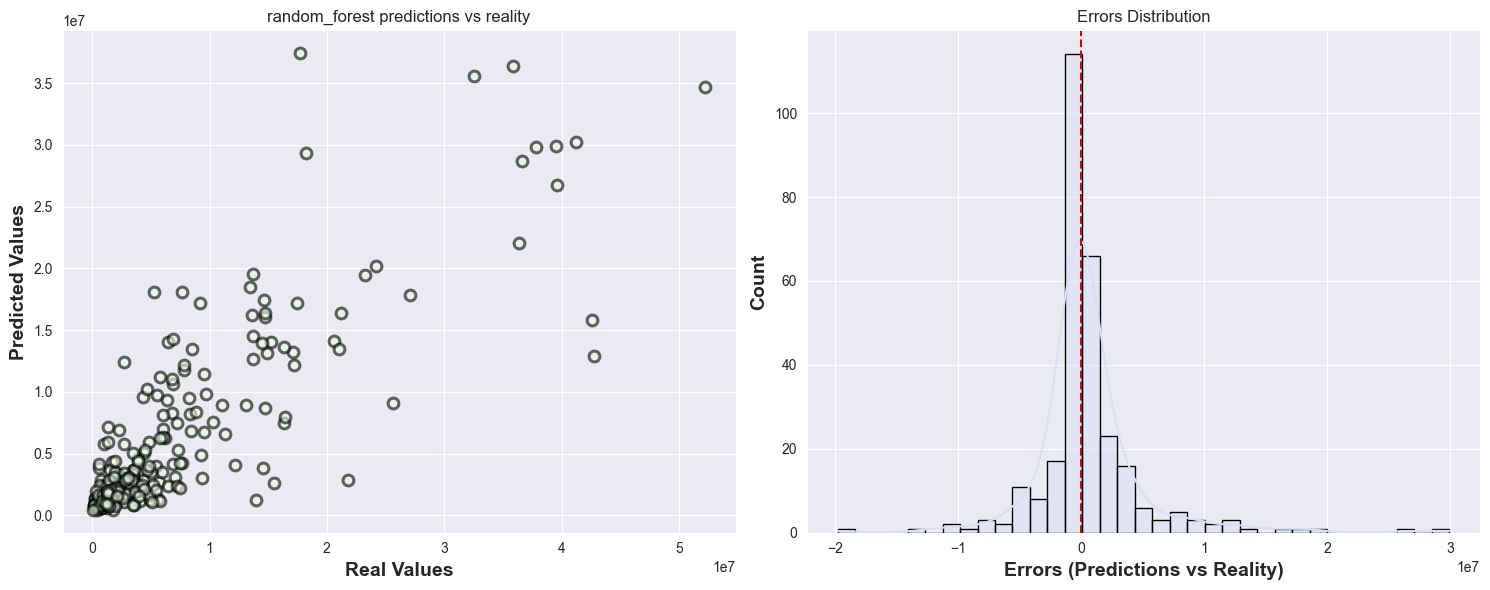

In [67]:
# let's plot the residuals
plot_residuals(y_true=y_test2,
               y_pred=y_pred_test2,
               model_name='random_forest')

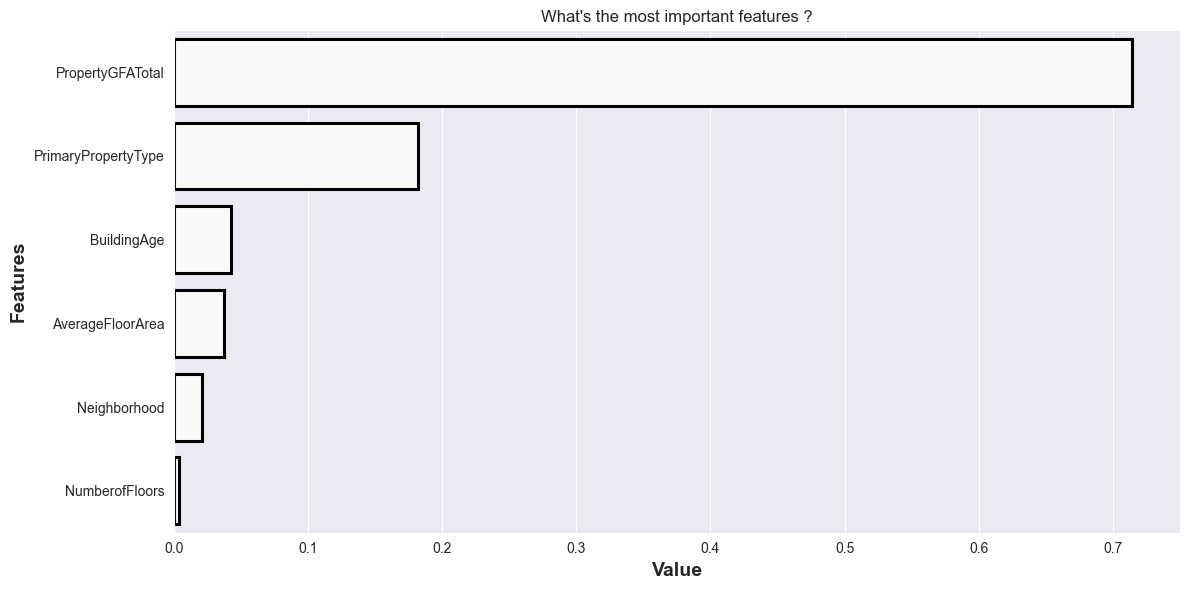

In [68]:
plot_features_importance(model=best_forest_model2,
                         feature_names=X_train2.columns.tolist())

In [69]:
print_feature_importances(model=best_forest_model2, feature_names=X_train2.columns.tolist())

,Features,Values
1,PropertyGFATotal,0.714387
0,PrimaryPropertyType,0.181731
4,BuildingAge,0.042398
5,AverageFloorArea,0.037211
2,Neighborhood,0.020722
3,NumberofFloors,0.003551


In [70]:
# so let's remove also the columns NumberofFloors to see teh evolution
X_train2_nf = X_train2.drop(columns='NumberofFloors')
X_test2_nf = X_test2.drop(columns='NumberofFloors')

In [71]:
# let's train another model: nf = NumberofFloors
best_forest_model3_without_nf = tune_model(model=base_model_forest,
                                           X_train=X_train2_nf,
                                           y_train=y_train2.squeeze(),
                                           model_type='random_forest',
                                           n_iter=30)

2026-02-17 22:36:28 | INFO     | energy_sights.modeling.tuning - Start of the tuning the: 2026-02-17 22:36:28.470400
2026-02-17 22:36:28.470 | INFO     | energy_sights.modeling.tuning:tune_model:47 - Start of the tuning the: 2026-02-17 22:36:28.470400
Fitting 5 folds for each of 30 candidates, totalling 150 fits
The best parameters finds are: {'regressor__model__n_estimators': 500, 'regressor__model__min_samples_split': 15, 'regressor__model__min_samples_leaf': 5, 'regressor__model__max_depth': 20, 'regressor__model__bootstrap': True}
The best Score (RMSE roughly): 5733876.95


In [72]:
# evaluation of the model: nf = NumberofFloors
# train set
y_pred_train_without_nf = best_forest_model3_without_nf.predict(X_train2_nf)

In [73]:
print_metrics(metrics=evaluate_regression(
    y_true=y_train2,
    y_pred=y_pred_train_without_nf,
    model_name='random_forest'
))


 Model performance : random_forest
  RMSE (Root Mean Squared Error) : 4,626,287.43
  MAE  (Mean Absolute Error)     : 2,104,573.95
  MAPE (Error %)           : 45.29%
  R²   (Score explication)  : 0.7215


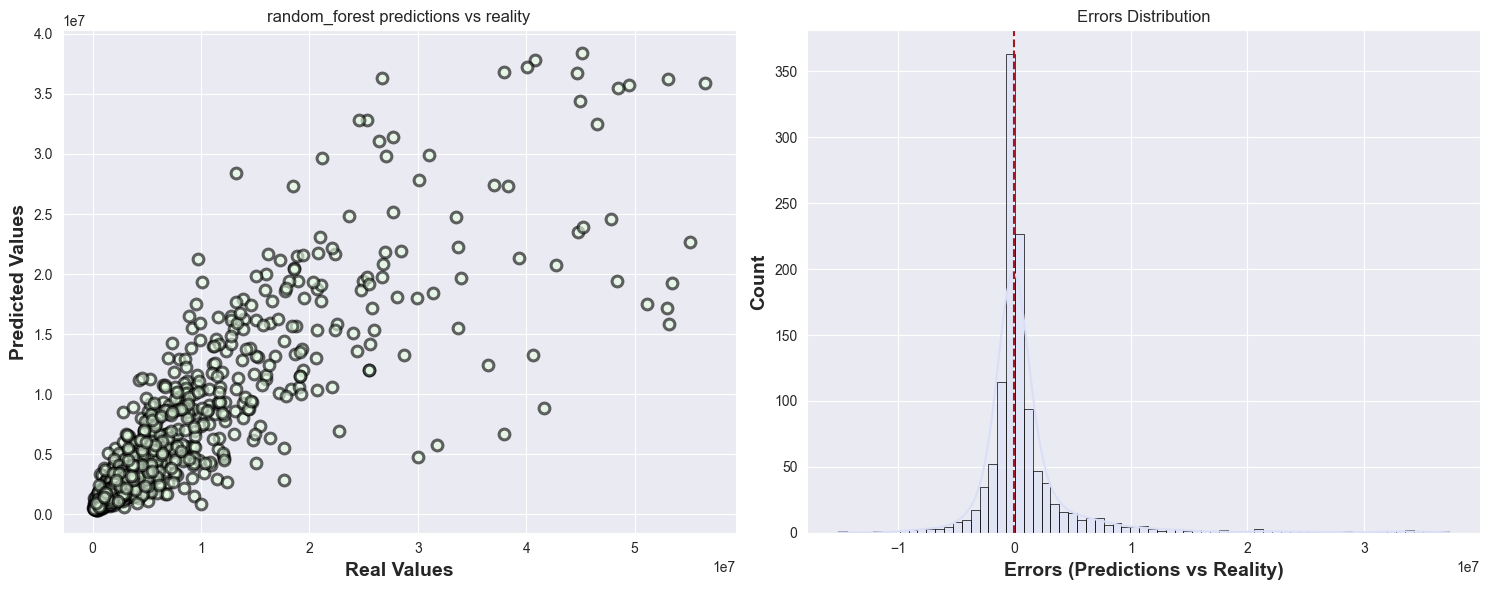

In [74]:
plot_residuals(y_true=y_train2,
               y_pred=y_pred_train_without_nf,
               model_name='random_forest')

In [75]:
y_pred_test_without_nf = best_forest_model3_without_nf.predict(X_test2_nf)

In [76]:
print_metrics(metrics=evaluate_regression(y_true=y_test2,
                                          y_pred=y_pred_test_without_nf,
                                          model_name='random_forest'))


 Model performance : random_forest
  RMSE (Root Mean Squared Error) : 4,617,258.10
  MAE  (Mean Absolute Error)     : 2,434,400.97
  MAPE (Error %)           : 67.09%
  R²   (Score explication)  : 0.7048


In [85]:
# let's save this model in production
trainer_forest.model = best_forest_model3_without_nf
trainer_forest.save_model(model_name='energy_model.pkl')

2026-02-17 23:19:29 | INFO     | energy_sights.modeling.train - Model saved this: 2026-02-17 23:19:29.373380 at C:\ML_projects\energy_sights\models\energy_model.pkl
2026-02-17 23:19:29.373 | INFO     | energy_sights.modeling.train:save_model:126 - Model saved this: 2026-02-17 23:19:29.373380 at C:\ML_projects\energy_sights\models\energy_model.pkl
